In [1]:
# Importation des librairies
import cv2
import os
import numpy as np
import torch
from torchvision import transforms
import time
import matplotlib.pyplot as plt

from ultralytics import YOLO
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation


In [2]:
# Définition des variables pour tous le TP

# Vérifie si un GPU est disponible et configure l'appareil
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

True


In [3]:
def unload_model(model):
    """Décharge proprement un modèle PyTorch du GPU."""
    if model is not None:
        del model
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def apply_yolo_model(image, model):
    results = model.predict(image, classes=TARGET_CLASSES, verbose=False)
    return results

def apply_clip_model(image, model, prompt, processor): #exemple pris de https://colab.research.google.com/github/gabilodeau/INF6804/blob/master/Zero_Shot_Segmentation.ipynb
    # Prétraitement de l'image et de la requête textuelle
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)
    
    # Inférence (mode évaluation)
    with torch.no_grad():
        results = model(**inputs)
    return results

In [4]:
# Fonction pour récupérer les fichiers images valides
def get_valid_image_files(folder, datasetname, dataname):
    
    if datasetname != "CDNET_2012": # pour une plage de frames des régions d'intéret
        image_files = sorted([f for f in os.listdir(folder) if os.path.splitext(f)[1].lower() in VALID_EXTENSIONS])
        return image_files
    else:
        temporal_roi_path = "../data/CDNET_2012/"+dataname+"/temporalROI.txt"
        with open(temporal_roi_path, 'r') as f:
            start_frame, end_frame = map(int, f.read().strip().split()) #suivant le fichier temporalROI.txt de chaque vidéo
        
        image_files = sorted([f for f in os.listdir(folder) if os.path.splitext(f)[1].lower() in VALID_EXTENSIONS]) # mettre dans l'odre des noms
        return [f for f in image_files if start_frame <= int(''.join(filter(str.isdigit, os.path.splitext(f)[0]))) <= end_frame] # Si <= début frame alors split les nombres et le texte puis verifie que le nombre est <= fin de frame
 


# Segmentation des images
def segment_images(input_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt=""):

    image_files = get_valid_image_files(input_folder, datasetname, dataname)

    if not os.path.exists(output_folder): #création du dossier si non existant
        os.makedirs(output_folder)

    for img_name in image_files:
        img_path = os.path.join(input_folder, img_name)
        image = cv2.imread(img_path)
        height, width = image.shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)  # Initialisation du masque noir par défaut
        
        if modelname == "YOLOseg":
            results = apply_yolo_model(image, model)
            if results[0].masks is not None:
                mask = results[0].masks.data.cpu().numpy()
                if mask.size > 0:
                    mask = np.any(mask, axis=0).astype(np.uint8) * 255
                    mask = cv2.resize(mask, (width, height))
        
        elif modelname == "CLIPseg":
            results = apply_clip_model(image, model, prompt, processor)
            # Appliquer la sigmoïde aux logits pour obtenir des probabilités et extraire le masque 2D
            pred_mask = results.logits.sigmoid().detach().cpu().numpy()[0]
            mask_binary = pred_mask > 0.5  # Seuillage pour obtenir un masque binaire
            if np.any(mask_binary):  # Vérifier si une segmentation a été détectée
                mask = (mask_binary.astype(np.uint8)) * 255
                mask = cv2.resize(mask, (width, height))
        
        cv2.imwrite(os.path.join(output_folder, img_name), mask)
    
    print(f"Segmentation terminée pour {len(image_files)} images.")

In [5]:
# Évaluation de la segmentation avec IoU

def calculate_iou(mask_pred, mask_gt):
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    return intersection / union if union != 0 else 0

def evaluate_segmentation(pred_folder, gt_folder, datasetname, dataname):
    pred_paths = get_valid_image_files(pred_folder, datasetname, dataname)
    gt_paths = get_valid_image_files(gt_folder, datasetname, dataname)

    assert len(pred_paths) == len(gt_paths), "Les dossiers doivent contenir le même nombre d'images."

    iou_scores = []

    for pred_name, gt_name in zip(pred_paths, gt_paths):
        pred_mask = cv2.imread(os.path.join(pred_folder, pred_name), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.imread(os.path.join(gt_folder, gt_name), cv2.IMREAD_GRAYSCALE)

        iou = calculate_iou(pred_mask, gt_mask)
        iou_scores.append(iou)
    
    #iou_scores = [iou for iou in iou_scores if iou > 0.0] # pour supprimer les non-detection

    moyenne_iou = sum(iou_scores) / len(iou_scores)
    
    return moyenne_iou, iou_scores

# Résultats hypothèse 1

quelle est la meilleure approche à utiliser si l’objet principal est un objet rare ?

Segmentation déjà effectuée pour ../results/YOLOseg/MoCA_Video/arctic_fox, aucune action nécessaire.
Moyenne IoU sur YOLOseg : 0.2342
Segmentation déjà effectuée pour ../results/CLIPseg/MoCA_Video/arctic_fox, aucune action nécessaire.
Moyenne IoU sur CLIPseg : 0.2243
Segmentation déjà effectuée pour ../results/YOLOseg/MoCA_Video/copperhead_snake, aucune action nécessaire.
Moyenne IoU sur YOLOseg : 0.0000
Segmentation déjà effectuée pour ../results/CLIPseg/MoCA_Video/copperhead_snake, aucune action nécessaire.
Moyenne IoU sur CLIPseg : 0.0021
Segmentation déjà effectuée pour ../results/YOLOseg/MoCA_Video/hedgehog_3, aucune action nécessaire.
Moyenne IoU sur YOLOseg : 0.0913
Segmentation déjà effectuée pour ../results/CLIPseg/MoCA_Video/hedgehog_3, aucune action nécessaire.
Moyenne IoU sur CLIPseg : 0.1428
Segmentation terminée pour 40 images.
Moyenne IoU sur YOLOseg : 0.0705
Segmentation terminée pour 40 images.
Moyenne IoU sur CLIPseg : 0.3473


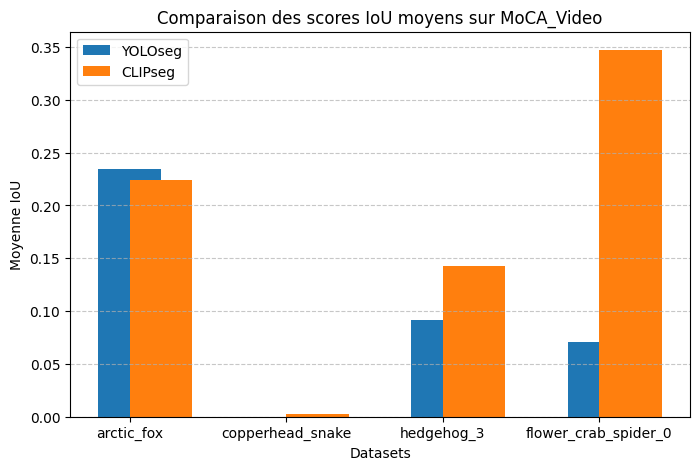

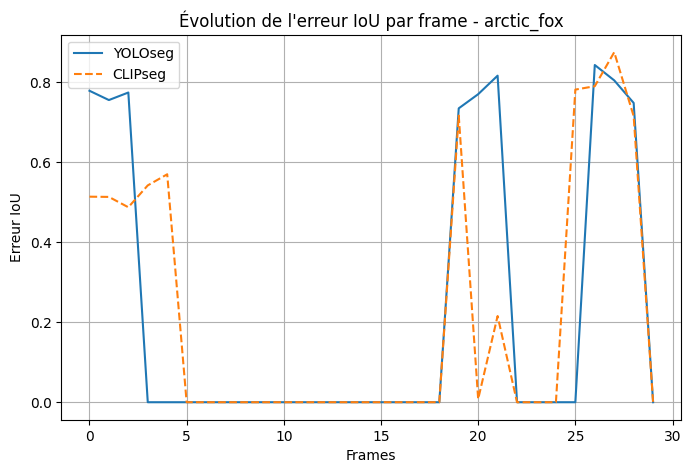

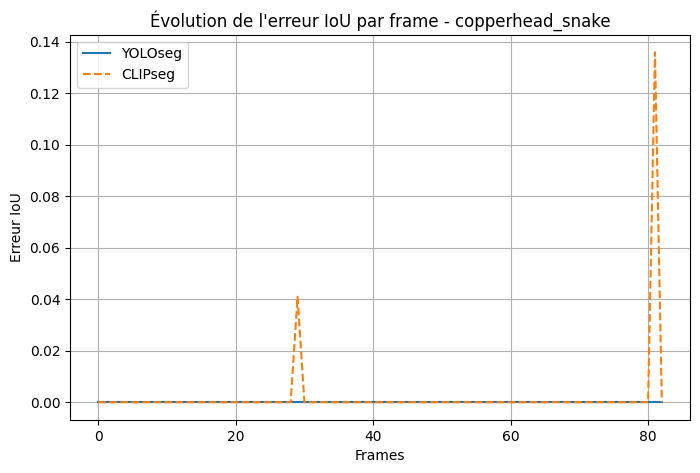

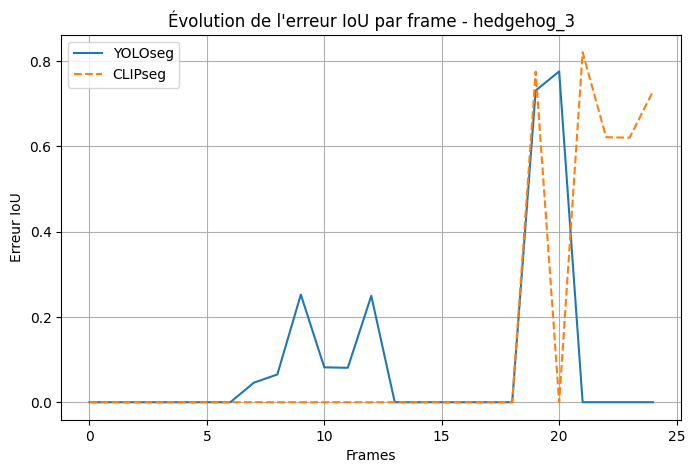

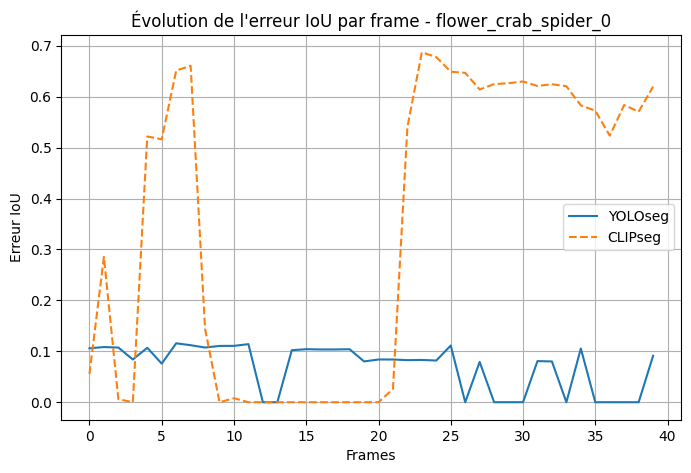

In [44]:
datasetname = "MoCA_Video"
datanames = ["arctic_fox", "copperhead_snake", "hedgehog_3", "flower_crab_spider_0"]

# Listes pour stocker les résultats globaux
iou_yoloseg = []
iou_clipseg = []
iou_scores_dict = {}  # Dictionnaire pour stocker les erreurs IoU par frame

def process_segmentation(dataname):
    global model
    global TARGET_CLASSES

    processor = None

    # YOLOseg :
    modelname = "YOLOseg"
    model = YOLO("../models/YOLOseg/yolo11n-seg.pt").to(device)

    # Choix des classes cibles
    TARGET_CLASSES = [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 77] if datasetname == "MoCA_Video" else []

    # Création des segmentations
    images_folder = f"../data/MoCA_Video/TestDataset_per_sq/{dataname}/Imgs"
    output_folder = f"../results/YOLOseg/{datasetname}/{dataname}"
    
    if os.path.exists(output_folder) and any(os.listdir(output_folder)):
        print(f"Segmentation déjà effectuée pour {output_folder}, aucune action nécessaire.")
    else:    
        segment_images(images_folder, output_folder, datasetname, dataname, modelname, model, processor)

    # Évaluation de la segmentation avec IoU sur YOLOseg
    groundtruth_folder = f"../data/MoCA_Video/TestDataset_per_sq/{dataname}/GT"
    moyenne_iou_YOLOseg, iou_scores_YOLOseg = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)

    print(f"Moyenne IoU sur YOLOseg : {moyenne_iou_YOLOseg:.4f}")
    iou_yoloseg.append(moyenne_iou_YOLOseg)

    # CLIPseg :
    unload_model(model)
    
    modelname = "CLIPseg"
    model_name = "CIDAS/clipseg-rd64-refined"
    processor = CLIPSegProcessor.from_pretrained(model_name)
    model = CLIPSegForImageSegmentation.from_pretrained(model_name).to(device)

    # Définition du prompt 
    if dataname == "arctic_fox":
        prompt = "an arctic fox"
    elif dataname == "copperhead_snake":
        prompt = "a snake"
    elif dataname == "hedgehog_3":
        prompt = "a small spiky animal"
    elif dataname == "flower_crab_spider_0":
        prompt = "a spider"

    # Création des segmentations
    output_folder = f"../results/CLIPseg/{datasetname}/{dataname}"
    
    if os.path.exists(output_folder) and any(os.listdir(output_folder)):
        print(f"Segmentation déjà effectuée pour {output_folder}, aucune action nécessaire.")
    else:    
        segment_images(images_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt)

    # Évaluation de la segmentation avec IoU sur CLIPseg
    moyenne_iou_CLIPseg, iou_scores_CLIPseg = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)

    print(f"Moyenne IoU sur CLIPseg : {moyenne_iou_CLIPseg:.4f}")
    iou_clipseg.append(moyenne_iou_CLIPseg)

    # Stocker les erreurs IoU par frame pour ce dataset
    iou_scores_dict[dataname] = {
        "frames": np.arange(len(iou_scores_YOLOseg)),  # Assumer que les frames sont indexées de 0 à N
        "iou_scores_YOLOseg": iou_scores_YOLOseg,
        "iou_scores_CLIPseg": iou_scores_CLIPseg
    }

    unload_model(model)

# Boucle sur tous les datasets définis
for dataname in datanames:
    process_segmentation(dataname)

# Tracer les résultats globaux
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Graphique des IoU moyens
ax.bar(datanames, iou_yoloseg, width=0.4, label="YOLOseg", align='center')
ax.bar(datanames, iou_clipseg, width=0.4, label="CLIPseg", align='edge')
ax.set_xlabel("Datasets")
ax.set_ylabel("Moyenne IoU")
ax.set_title(f"Comparaison des scores IoU moyens sur {datasetname}")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Générer un graphique pour chaque dataset montrant les erreurs IoU par frame
for dataname in datanames:
    if dataname in iou_scores_dict:
        frames = iou_scores_dict[dataname]["frames"]
        iou_scores_YOLOseg = iou_scores_dict[dataname]["iou_scores_YOLOseg"]
        iou_scores_CLIPseg = iou_scores_dict[dataname]["iou_scores_CLIPseg"]

        plt.figure(figsize=(8, 5))
        plt.plot(frames, iou_scores_YOLOseg, label="YOLOseg", linestyle="-")
        plt.plot(frames, iou_scores_CLIPseg, label="CLIPseg", linestyle="--")

        plt.xlabel("Frames")
        plt.ylabel("Erreur IoU")
        plt.title(f"Évolution de l'erreur IoU par frame - {dataname}")
        plt.legend()
        plt.grid()
        plt.show()



# Résultats hypothèse 2

Quelle est la meilleure approche pour segmenter un objet, si l’objet est une classe connu (personne, voiture,…) ?

Moyenne IoU sur YOLOseg pour highway : 0.7022, Temps : 0.00 sec
Moyenne IoU sur CLIPseg pour highway : 0.6734, Temps : 0.00 sec
Moyenne IoU sur YOLOseg pour office : 0.8034, Temps : 0.00 sec
Moyenne IoU sur CLIPseg pour office : 0.7485, Temps : 0.00 sec
Moyenne IoU sur YOLOseg pour pedestrians : 0.4628, Temps : 0.00 sec
Moyenne IoU sur CLIPseg pour pedestrians : 0.4382, Temps : 0.00 sec
Moyenne IoU sur YOLOseg pour PETS2006 : 0.6887, Temps : 0.00 sec
Moyenne IoU sur CLIPseg pour PETS2006 : 0.5447, Temps : 0.00 sec


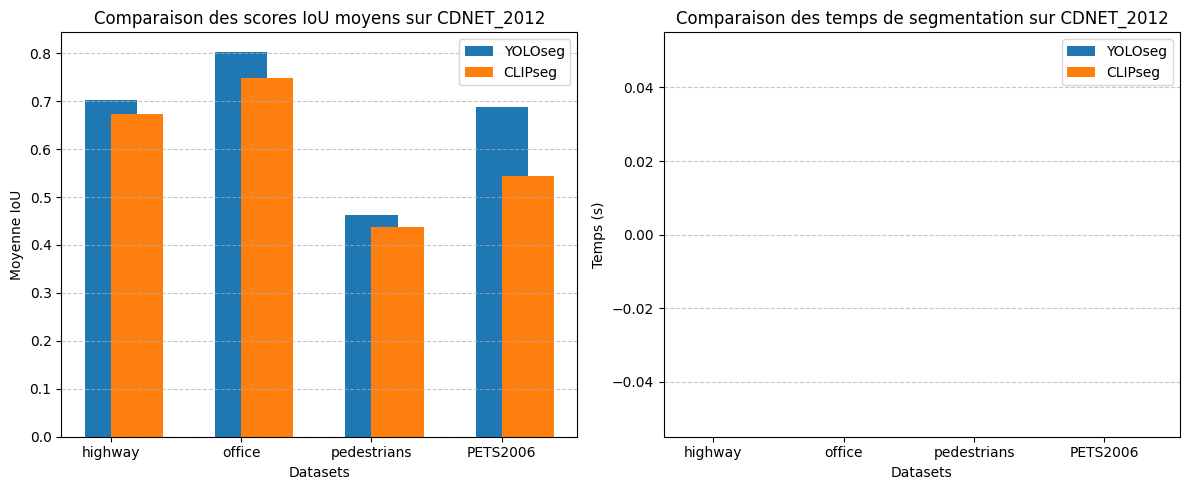

In [36]:
# Définition du dataset principal
datasetname = "CDNET_2012"
datanames = ["highway", "office", "pedestrians", "PETS2006"]

# Listes pour stocker les résultats
iou_yoloseg = []
iou_clipseg = []
time_yoloseg = []
time_clipseg = []

def process_segmentation(dataname):
    global model
    global TARGET_CLASSES
    # YOLOseg :
    modelname = "YOLOseg"
    model = YOLO("../models/YOLOseg/yolo11n-seg.pt").to(device)

    TARGET_CLASSES = [2] if dataname == "highway" else [0]

    images_folder = f"../data/{datasetname}/{dataname}/input"
    output_folder = f"../results/YOLOseg/{datasetname}/{dataname}"

    if not os.path.exists(output_folder) or not any(os.listdir(output_folder)):
        start_time_yoloseg = time.time()
        segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt)
        end_time_yoloseg = time.time()
        elapsed_time_yoloseg = end_time_yoloseg - start_time_yoloseg
    else:
        elapsed_time_yoloseg = 0  # Si déjà segmenté, pas de temps supplémentaire

    groundtruth_folder = f"../data/{datasetname}/{dataname}/groundtruth"
    moyenne_iou_YOLOseg, _  = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    
    print(f"Moyenne IoU sur YOLOseg pour {dataname} : {moyenne_iou_YOLOseg:.4f}, Temps : {elapsed_time_yoloseg:.2f} sec")
    iou_yoloseg.append(moyenne_iou_YOLOseg)
    time_yoloseg.append(elapsed_time_yoloseg)

    # CLIPseg :
    unload_model(model)
    modelname = "CLIPseg"
    model_name = "CIDAS/clipseg-rd64-refined"
    processor = CLIPSegProcessor.from_pretrained(model_name)
    model = CLIPSegForImageSegmentation.from_pretrained(model_name).to(device)

    prompt = "a car" if dataname == "highway" else "a person"
    output_folder = f"../results/CLIPseg/{datasetname}/{dataname}"

    if not os.path.exists(output_folder) or not any(os.listdir(output_folder)):
        start_time_clipseg = time.time()
        segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt)
        end_time_clipseg = time.time()
        elapsed_time_clipseg = end_time_clipseg - start_time_clipseg
    else:
        elapsed_time_clipseg = 0  # Si déjà segmenté, pas de temps supplémentaire

    moyenne_iou_CLIPseg, _ = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    
    print(f"Moyenne IoU sur CLIPseg pour {dataname} : {moyenne_iou_CLIPseg:.4f}, Temps : {elapsed_time_clipseg:.2f} sec")
    iou_clipseg.append(moyenne_iou_CLIPseg)
    time_clipseg.append(elapsed_time_clipseg)

    unload_model(model)

# Boucle sur tous les datasets définis
for dataname in datanames:
    process_segmentation(dataname)

# Trace les résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique des IoU
axes[0].bar(datanames, iou_yoloseg, width=0.4, label="YOLOseg", align='center')
axes[0].bar(datanames, iou_clipseg, width=0.4, label="CLIPseg", align='edge')
axes[0].set_xlabel("Datasets")
axes[0].set_ylabel("Moyenne IoU")
axes[0].set_title("Comparaison des scores IoU moyens sur CDNET_2012")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Graphique des temps de segmentation
axes[1].bar(datanames, time_yoloseg, width=0.4, label="YOLOseg", align='center')
axes[1].bar(datanames, time_clipseg, width=0.4, label="CLIPseg", align='edge')
axes[1].set_xlabel("Datasets")
axes[1].set_ylabel("Temps (s)")
axes[1].set_title("Comparaison des temps de segmentation sur CDNET_2012")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# Résultats hypothèse 3

Quelle est la meilleure approche pour segmenter un objet si la vidéo contient du bruit (Flou, neige/pluie, …) ?

Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise
Segmentation terminée pour 1231 images.
Moyenne IoU sur YOLOseg pour highway : 0.1382
Segmentation terminée pour 1231 images.
Moyenne IoU sur CLIPseg pour highway : 0.5480
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/office/input_noise
Segmentation terminée pour 1481 images.
Moyenne IoU sur YOLOseg pour office : 0.5733
Segmentation terminée pour 1481 images.
Moyenne IoU sur CLIPseg pour office : 0.6041
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/pedestrians/input_noise
Segmentation terminée pour 800 images.
Moyenne IoU sur YOLOseg pour pedestrians : 0.4136
Segmentation terminée pour 800 images.
Moyenne IoU sur CLIPseg pour pedestrians : 0.4438
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/PETS2006/input_noise
Segmentation terminée pour 901 images.
Moyenne IoU sur YOLOseg pour PETS2006 : 0.3279
Segmentation terminée pour 901 images.
Moyenne IoU sur CLIPseg

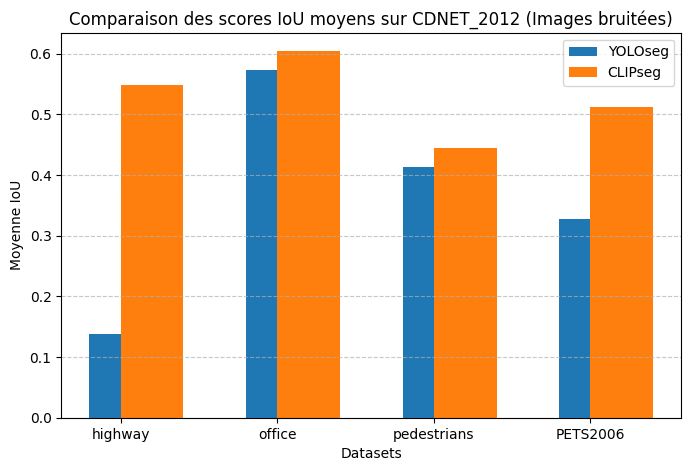

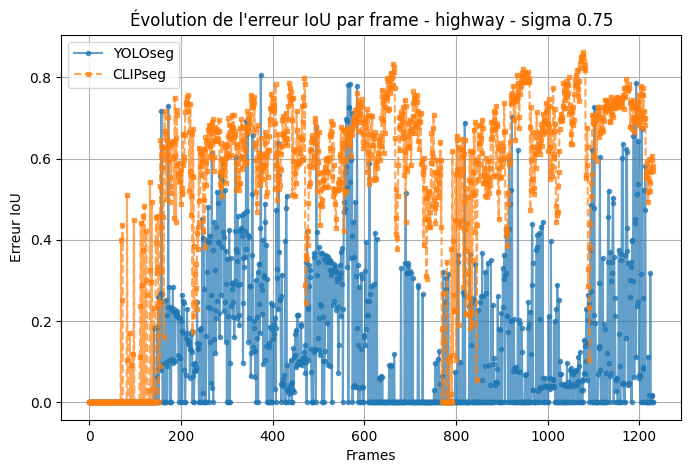

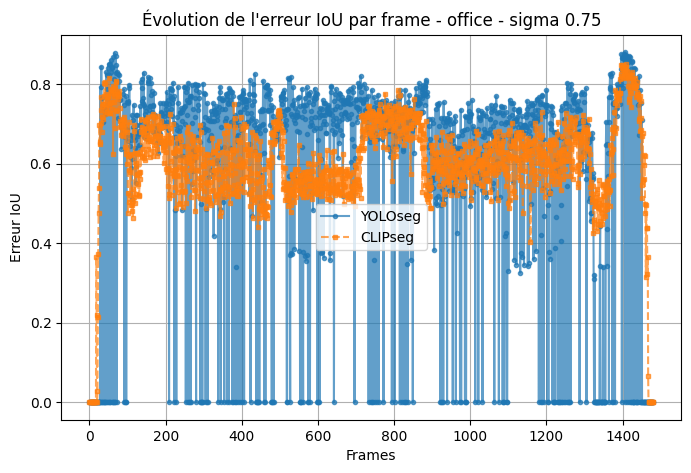

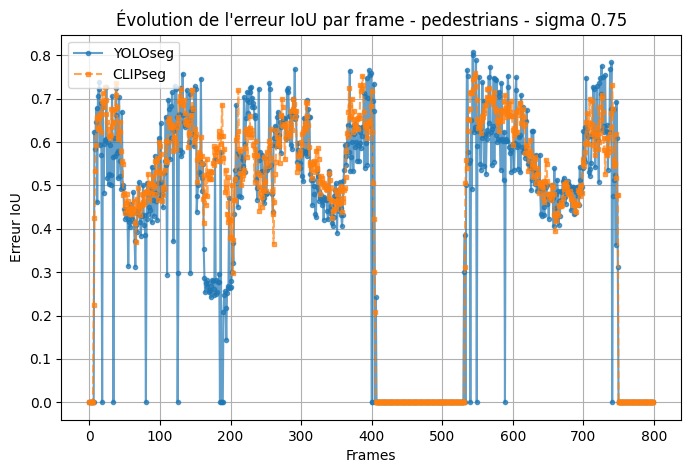

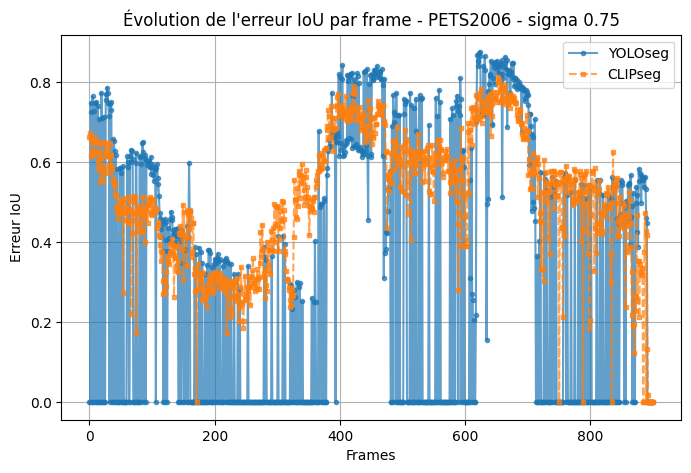

In [32]:
datasetname = "CDNET_2012"
datanames = ["highway", "office", "pedestrians", "PETS2006"]
SIGMA_NOISE = [0, 0.25, 0.5, 0.75, 1]  # Intensité du bruit

# Listes pour stocker les résultats
iou_yoloseg = []
iou_clipseg = []
iou_scores_dict = {}

def add_noise(image, noise_type="gaussian"):
    """
    Ajoute du bruit à une image.
    - "gaussian" : bruit gaussien
    - "salt_pepper" : bruit poivre et sel
    """
    if noise_type == "gaussian":
        mean = 0
        sigma = SIGMA_NOISE
        gauss = np.random.normal(mean, sigma, image.shape).astype(np.uint8)
        noisy_image = cv2.add(image, gauss)
    elif noise_type == "salt_pepper":
        s_vs_p = 0.005  # Ratio sel/poivre
        noisy_image = np.copy(image)
        
        # Ajouter du sel (pixels blancs)
        num_salt = np.ceil(s_vs_p * image.size * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape[:2]]
        noisy_image[coords[0], coords[1]] = 255

        # Ajouter du poivre (pixels noirs)
        num_pepper = np.ceil(s_vs_p * image.size * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape[:2]]
        noisy_image[coords[0], coords[1]] = 0
    else:
        noisy_image = image  # Si type inconnu, ne pas modifier l'image

    return noisy_image

def add_noise_to_images(images_folder, output_folder, noise_type="gaussian"):
    """
    Ajoute du bruit aux images d'un dossier et les enregistre dans un autre dossier.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for img_name in os.listdir(images_folder):
        img_path = os.path.join(images_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue  # Si l'image ne se charge pas, passer

        noisy_img = add_noise(img, noise_type)
        cv2.imwrite(os.path.join(output_folder, img_name), noisy_img)

    print(f"Bruit ajouté et images enregistrées dans : {output_folder}")


def process_segmentation(dataname):
    global model
    global TARGET_CLASSES
    
    processor = None

    images_folder = f"../data/{datasetname}/{dataname}/input"
    noisy_images_folder = f"../data/{datasetname}/{dataname}/input_noise"

    if not os.path.exists(noisy_images_folder) or not any(os.listdir(noisy_images_folder)):
        add_noise_to_images(images_folder, noisy_images_folder, noise_type="gaussian")

#--------------------------------------------------------------------------------------------------------------------------------------
    # YOLOseg :
    modelname = "YOLOseg"
    model_path = "../models/YOLOseg/yolo11n-seg.pt"
    model = YOLO(model_path).to(device)

    TARGET_CLASSES = [2] if dataname == "highway" else [0]

    output_folder = f"../results/YOLOseg/{datasetname}/{dataname}_noise"
    
    if not os.path.exists(output_folder) or not any(os.listdir(output_folder)):
        segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, processor)

    groundtruth_folder = f"../data/{datasetname}/{dataname}/groundtruth"
    moyenne_iou_YOLOseg, iou_scores_YOLOseg = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    
    print(f"Moyenne IoU sur YOLOseg pour {dataname} : {moyenne_iou_YOLOseg:.4f}")
    iou_yoloseg.append(moyenne_iou_YOLOseg)

#--------------------------------------------------------------------------------------------------------------------------------------
    # CLIPseg :
    unload_model(model)
    modelname = "CLIPseg"
    model_name = "CIDAS/clipseg-rd64-refined"

    processor = CLIPSegProcessor.from_pretrained(model_name)
    model = CLIPSegForImageSegmentation.from_pretrained(model_name).to(device)

    prompt = "a car" if dataname == "highway" else "a person"

    output_folder = f"../results/CLIPseg/{datasetname}/{dataname}_noise"

    if not os.path.exists(output_folder) or not any(os.listdir(output_folder)):
        segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt)
    moyenne_iou_CLIPseg, iou_scores_CLIPseg = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    
    print(f"Moyenne IoU sur CLIPseg pour {dataname} : {moyenne_iou_CLIPseg:.4f}")
    iou_clipseg.append(moyenne_iou_CLIPseg)

    unload_model(model)

    # Stocker les erreurs IoU par frame
    iou_scores_dict[dataname] = {
        "frames": np.arange(len(iou_scores_YOLOseg)),
        "iou_scores_YOLOseg": iou_scores_YOLOseg,
        "iou_scores_CLIPseg": iou_scores_CLIPseg
    }

# Boucle sur tous les datasets définis
for dataname in datanames:
    process_segmentation(dataname)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Graphique des IoU moyens
ax.bar(datanames, iou_yoloseg, width=0.4, label="YOLOseg", align='center')
ax.bar(datanames, iou_clipseg, width=0.4, label="CLIPseg", align='edge')
ax.set_xlabel("Datasets")
ax.set_ylabel("Moyenne IoU")
ax.set_title(f"Comparaison des scores IoU moyens sur {datasetname} (Images bruitées)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# Générer un graphique par dataset pour les erreurs IoU par frame
for dataname in datanames:
    if dataname in iou_scores_dict:
        frames = iou_scores_dict[dataname]["frames"]
        iou_scores_YOLOseg = iou_scores_dict[dataname]["iou_scores_YOLOseg"]
        iou_scores_CLIPseg = iou_scores_dict[dataname]["iou_scores_CLIPseg"]

        plt.figure(figsize=(8, 5))
        plt.plot(frames, iou_scores_YOLOseg, label="YOLOseg",linestyle="-", alpha=0.7)
        plt.plot(frames, iou_scores_CLIPseg, label="CLIPseg",linestyle="--", alpha=0.7)

        plt.xlabel("Frames")
        plt.ylabel("Erreur IoU")
        plt.title(f"Évolution de l'erreur IoU par frame - {dataname} - sigma {SIGMA_NOISE}")
        plt.legend()
        plt.grid()
        plt.show()


## évolution de l'erreur par rapport au bruit

Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise\noise_0
Segmentation terminée pour 1231 images.
Segmentation terminée pour 1231 images.
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise\noise_0.25
Segmentation terminée pour 1231 images.
Segmentation terminée pour 1231 images.
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise\noise_0.5
Segmentation terminée pour 1231 images.
Segmentation terminée pour 1231 images.
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise\noise_0.75
Segmentation terminée pour 1231 images.
Segmentation terminée pour 1231 images.
Bruit ajouté et images enregistrées dans : ../data/CDNET_2012/highway/input_noise\noise_1
Segmentation terminée pour 1231 images.
Segmentation terminée pour 1231 images.


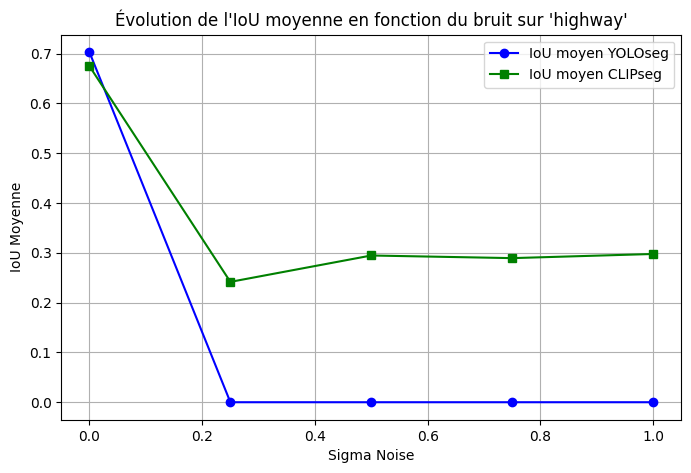

In [7]:
# Définition des paramètres
datasetname = "CDNET_2012"
dataname = "highway"
SIGMA_NOISE = [0, 0.25, 0.5, 0.75, 1]  # Intensité du bruit

def add_noise(image, sigma):
    """
    Ajoute du bruit gaussien à une image avec l'intensité spécifiée.
    """
    mean = 0
    gauss = np.random.normal(mean, sigma * 255, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, gauss)
    return noisy_image

def add_noise_to_images(images_folder, output_folder, sigma):
    """
    Ajoute du bruit aux images d'un dossier et les enregistre dans un autre dossier.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for img_name in os.listdir(images_folder):
        img_path = os.path.join(images_folder, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue  # Si l'image ne se charge pas, passer

        noisy_img = add_noise(img, sigma)
        cv2.imwrite(os.path.join(output_folder, img_name), noisy_img)

    print(f"Bruit ajouté et images enregistrées dans : {output_folder}")

iou_yoloseg = []
iou_clipseg = []

images_folder = f"../data/{datasetname}/{dataname}/input"
noisy_images_root = f"../data/{datasetname}/{dataname}/input_noise"

groundtruth_folder = f"../data/{datasetname}/{dataname}/groundtruth"

for sigma in SIGMA_NOISE:
    noisy_images_folder = os.path.join(noisy_images_root, f"noise_{sigma}")
    add_noise_to_images(images_folder, noisy_images_folder, sigma)

    # YOLOseg
    modelname = "YOLOseg"
    model_path = "../models/YOLOseg/yolo11n-seg.pt"
    model = YOLO(model_path).to(device)

    TARGET_CLASSES = [2] if dataname == "highway" else [0]
    output_folder = f"../results/YOLOseg/{datasetname}/{dataname}_noise_{sigma}"
    segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, None)
    
    moyenne_iou_YOLOseg, _ = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    iou_yoloseg.append(moyenne_iou_YOLOseg)
    
    # CLIPseg
    unload_model(model)
    modelname = "CLIPseg"
    model_name = "CIDAS/clipseg-rd64-refined"
    processor = CLIPSegProcessor.from_pretrained(model_name)
    model = CLIPSegForImageSegmentation.from_pretrained(model_name).to(device)
    
    prompt = "a car"
    output_folder = f"../results/CLIPseg/{datasetname}/{dataname}_noise_{sigma}"
    segment_images(noisy_images_folder, output_folder, datasetname, dataname, modelname, model, processor, prompt)
    moyenne_iou_CLIPseg, _ = evaluate_segmentation(output_folder, groundtruth_folder, datasetname, dataname)
    iou_clipseg.append(moyenne_iou_CLIPseg)
    
    unload_model(model)

# Création du graphique de l'évolution du bruit et de l'IoU moyenne
plt.figure(figsize=(8, 5))
plt.plot(SIGMA_NOISE, iou_yoloseg, marker='o', linestyle='-', color='b', label='IoU moyen YOLOseg')
plt.plot(SIGMA_NOISE, iou_clipseg, marker='s', linestyle='-', color='g', label='IoU moyen CLIPseg')
plt.xlabel("Sigma Noise")
plt.ylabel("IoU Moyenne")
plt.title("Évolution de l'IoU moyenne en fonction du bruit sur 'highway'")
plt.legend()
plt.grid(True)
plt.show()